In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv("AB_NYC_2019.csv")

df = df_raw.copy()

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [41]:
print("Shape:", df.shape)
df.info()

Shape: (48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review  

In [42]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing = missing[missing["missing_count"] > 0].sort_values("missing_percent", ascending=False)
missing

,missing_count,missing_percent
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723


In [43]:
df = df.drop(columns=["name", "host_name", "last_review"])

In [44]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

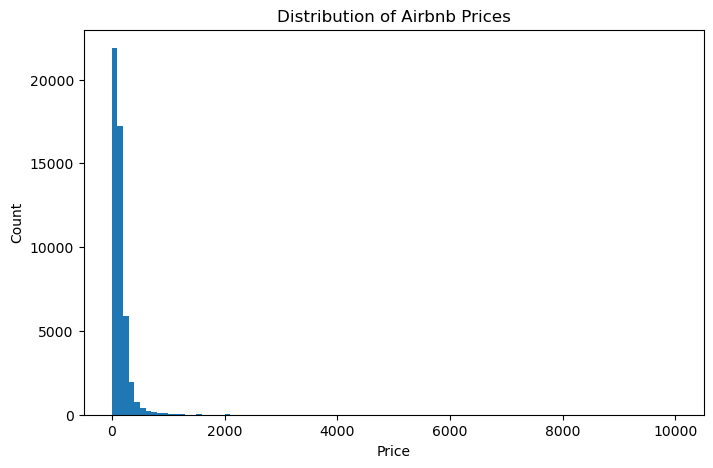

In [45]:
df["price"].describe()
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=100)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Airbnb Prices")
plt.show()

In [46]:
df = df[df["price"] > 0]

print("Shape after removing zero prices:", df.shape)

Shape after removing zero prices: (48884, 13)


In [47]:
df["price"].quantile([0.90, 0.95, 0.99, 0.995, 1.00])

0.900      269.0
0.950      355.0
0.990      799.0
0.995     1000.0
1.000    10000.0
Name: price, dtype: float64

In [48]:
price_upper = df["price"].quantile(0.99)

df = df[df["price"] <= price_upper].copy()

print("99th percentile price cutoff:", price_upper)
print("Shape after removing extreme price outliers:", df.shape)
print(df["price"].describe())

99th percentile price cutoff: 799.0
Shape after removing extreme price outliers: (48410, 13)
count    48410.000000
mean       137.575170
std        103.780081
min         10.000000
25%         69.000000
50%        105.000000
75%        175.000000
max        799.000000
Name: price, dtype: float64


In [49]:
df["minimum_nights"].describe()

count    48410.000000
mean         6.979508
std         20.293249
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [50]:
df["minimum_nights"].quantile([0.90, 0.95, 0.99, 1.00])

0.90      28.0
0.95      30.0
0.99      40.0
1.00    1250.0
Name: minimum_nights, dtype: float64

In [51]:
min_nights_upper = df["minimum_nights"].quantile(0.99)

df = df[df["minimum_nights"] <= min_nights_upper]

print("99th percentile minimum_nights cutoff:", min_nights_upper)
print("Shape after removing extreme minimum_nights:", df.shape)

99th percentile minimum_nights cutoff: 40.0
Shape after removing extreme minimum_nights: (47928, 13)


In [52]:
df["availability_365"].describe()

count    47928.000000
mean       111.484915
std        131.016075
min          0.000000
25%          0.000000
50%         43.000000
75%        222.000000
max        365.000000
Name: availability_365, dtype: float64

In [53]:
df = df[(df["availability_365"] >= 0) & (df["availability_365"] <= 365)]

In [54]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21045
Brooklyn         19821
Queens            5619
Bronx             1075
Staten Island      368
Name: count, dtype: int64

In [55]:
df["room_type"].value_counts()

room_type
Entire home/apt    24707
Private room       22082
Shared room         1139
Name: count, dtype: int64

In [56]:
df["neighbourhood"].nunique()

220

In [57]:
df["log_price"] = np.log1p(df["price"])

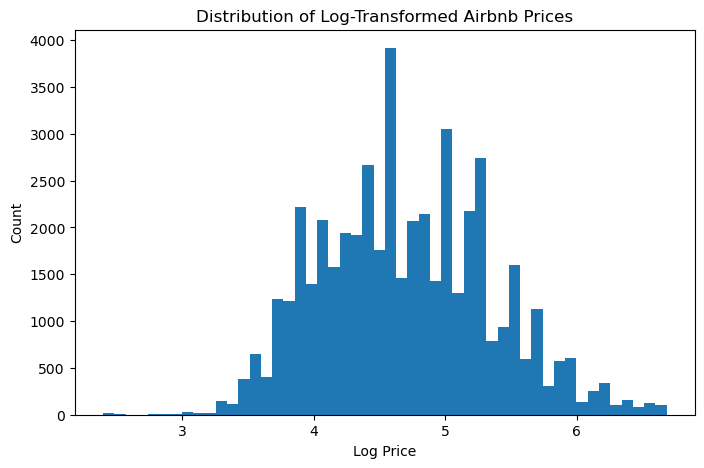

In [58]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=50)
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.show()

In [59]:
df.isnull().sum()

id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
log_price                         0
dtype: int64

In [60]:
print("Final shape:", df.shape)
df.head()

Final shape: (47928, 14)


,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449


In [61]:
df.to_csv("cleaned_data.csv", index=False)

In [62]:
df.shape

(47928, 14)

In [63]:
df.isnull().sum()

id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
log_price                         0
dtype: int64

In [64]:
df[["price", "log_price", "minimum_nights", "number_of_reviews", "reviews_per_month", "availability_365"]].describe()

,price,log_price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
count,47928.000000,47928.000000,47928.000000,47928.000000,47928.000000,47928.000000
mean,137.653209,4.713972,5.709126,23.545568,1.105395,111.484915
std,103.927713,0.647422,8.383021,44.809209,1.605936,131.016075
min,10.000000,2.397895,1.000000,0.000000,0.000000,0.000000
25%,69.000000,4.248495,1.000000,1.000000,0.040000,0.000000
50%,105.000000,4.663439,2.000000,5.000000,0.380000,43.000000
75%,175.000000,5.170484,5.000000,24.000000,1.620000,222.000000
max,799.000000,6.684612,40.000000,629.000000,58.500000,365.000000
